# K-Means clustering

Overview

Online retail is a transnational data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail. The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.


The steps are broadly:


1. Read and understand the data
2. Clean the data
3. Prepare the data for modelling
4. Modelling
5. Final analysis and reco

### Lets import the required libraries 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
retail = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\IIIT-B\Data science\Machine Learning\Unsupervised Learning Clustering\Online+Retail.csv",header=0, encoding='windows-1252')
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,1/12/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,1/12/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,1/12/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,1/12/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,1/12/2010 8:26,3.39,17850.0,United Kingdom


### Lets look at the shape of the data set

In [4]:
retail.shape

(541909, 8)

In [5]:
retail.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Now that you've understood what to do with the dataset, it's always a good idea to start with cleaning the data first

Lets check the missing values on the data set 

In [7]:
retail.isnull()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
541904,False,False,False,False,False,False,False,False
541905,False,False,False,False,False,False,False,False
541906,False,False,False,False,False,False,False,False
541907,False,False,False,False,False,False,False,False


In [8]:
retail.isnull().value_counts()

InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  CustomerID  Country
False      False      False        False     False        False      False       False      406829
                                                                     True        False      133626
                      True         False     False        False      True        False        1454
Name: count, dtype: int64

In [9]:
retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

##### we can see there are missing values in the columns Description and Customer ID

### Lets see the percentage of the missing values 

In [10]:
round(100*(retail.isnull().sum())/len(retail),2)

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

#### We have around 25% of missing values on the customer id - do we need to drop the customer id columns 
#### if we drop the customer id columns then it is kind of missing the customer information itself - better we will drop customer id missing value rows

### we can drop the customer id rows whever is blank - mean which ever is missing

### Coming to the next missing values which is Description - its just 27% - better we can drop this missing rows 

### Removing the missing values of the data set 

In [11]:
retail = retail.dropna()
retail.shape

(406829, 8)

# 3 Preparing the data for modelling 

for data preparation we dont no where to start - as we discussed earlier - we can use RFM method to start our cluster proceess

RFE

R - Recency - When was the last purchase from last 30 days (No of days since last purchase)

F - Frequency - How frequently the customer has purchased from last one year (Number of Transactions)

M - Monetary - The Revenue spent by the customer from last one year (Revenue Cotribution)

Finally we need a data set as below 

Customer ID           Recency              Frequency                  Monetary

Lets strat find the values of RFE - now lets get started with Monetay 1st and then later we will go with Recency and Frequency

### Monetary

##### To calculate Monetary we need to multiply Quantity and Unitprice - and add a new column called amount in the df

In [12]:
retail['Amount'] = retail['Quantity']*retail['UnitPrice']
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


#### using the new column amount - we can calculate the monetary 
So how we will calculate the monetary using the newly added column money 
we can just group by the customer id and add up the amounts based on the customer id then we can calculate the Monetary 

#### Lets calculate the Monetary using the customer id and amount 

In [13]:
grouped = retail.groupby('CustomerID') ['Amount'].sum()
grouped = grouped.reset_index()
grouped.head()

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


### Now lets create the second matrix - Frequency

#### Lets see how to compute the values for Frequency

In [14]:
frequency = retail.groupby('CustomerID') ['InvoiceNo'].count()
frequency = frequency.reset_index()
frequency.columns = ['CustomerID', 'Frequency']
frequency.head()

,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [15]:
df = pd.merge(grouped, frequency,how = 'inner', on = 'CustomerID')
df.head()

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


### Now lets move to the next matrix - Recency 
Lets see how to calculate the Recency matrix


We can see the data is from-between 01/12/2010 and 09/12/2011


Calculation method - Take the date of transaction and compute that with the 09/12/2011 - then you will get the no of days of last transaction (Basically the days elapsed inbetween the transaction date and reference date)

09/12/2011 - is our reference date 

for example 

if a customer having 5 type of transation inbetween the dates which mentioned above 
300 days agao, 200 days ago, 100 days ago, 50 days ago , 2days ago 
recency should be 4 for this customer


In [16]:
#### Lets see the date columns to check what kind of dat it is
retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
 8   Amount       406829 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 31.0+ MB


#### You can see the Invoice date is what we want to consider - here the data type is object which means string 
#### Lets change that into date formate which will help us for our calculation 

Lets see how to do that using Pandas libraries 

we have a module called pd.to_datatime

In [17]:
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'], 
                                     format = '%d-%m-%Y %H:%M')
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


##### Now lets check the InvoiceDate column data type 

In [18]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
 8   Amount       406829 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.0+ MB


##### Now we can see the datetime data type has been updated to InvoiceDate columns 

##### Now we have to find the difference between the transaction date and the reference date 
##### So 1st we need to find the what is the refernece date - from the InvoiceDate column 
##### Lets see how to do that 

In [19]:
max_date = max(retail['InvoiceDate'])
max_date

Timestamp('2011-12-09 12:50:00')

##### So from the date sheet we got the confirmation that 09-12-2011 is the last or max or reference date 
##### Now lets calculate the difference of the transaction and max date to find the actual no of days 

In [20]:
retail['diff'] = (max_date - retail['InvoiceDate'])
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00


##### So now we have got the last transaction date of all the invoice or invoice dates 
##### Now lets see how to consolidate all the last transaction to the respective customers 
##### Eg Customer 1 has 5 transaction and from that 5 transaction we need to map the last transaction date to the respective customer
##### Using Group by we will do the mapping of the last transaction date 

In [21]:
last_transaction = retail.groupby('CustomerID')['diff'].min()
last_transaction = last_transaction.reset_index()
last_transaction.head()

,CustomerID,diff
0,12346.0,325 days 02:33:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00


Finally we have calculated the last transaction date for all the customers 


now lets add that column into our grouped df to and then later into main df 

In [22]:
df1 = pd.merge(df, last_transaction ,how = 'inner', on = 'CustomerID')
df1.head()

,CustomerID,Amount,Frequency,diff
0,12346.0,0.00,2,325 days 02:33:00
1,12347.0,4310.00,182,1 days 20:58:00
2,12348.0,1797.24,31,74 days 23:37:00
3,12349.0,1757.55,73,18 days 02:59:00
4,12350.0,334.40,17,309 days 20:49:00


##### Now lets rename all the columns according to RFM

In [23]:
df1.columns

Index(['CustomerID', 'Amount', 'Frequency', 'diff'], dtype='object')

In [24]:
df1.columns = ['CustomerID', 'Amount', 'Frequency', 'Recency']
df1.head()

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325 days 02:33:00
1,12347.0,4310.00,182,1 days 20:58:00
2,12348.0,1797.24,31,74 days 23:37:00
3,12349.0,1757.55,73,18 days 02:59:00
4,12350.0,334.40,17,309 days 20:49:00


#### so till now we have calculated the Monetary Frequency & Recency - RFM 

# Data Preparation - II
The next important concepts that need to be applied in the data preparation stage are outlier treatment and standardisation of the data. 

Let's understand both of them in detail.

##### Lets remove the time from the Recency columns as this makes no sense for our prediction 
##### To remove the time from the column we have a library date time 
##### Lets try to import that library and see how we can remove ti 

In [25]:
import datetime as dt

In [26]:
df1['Recency'] = df1['Recency'].dt.days
df1.head()

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309


# There are 2 main steps during Clustering Outlier treatment & Rescaling 

## Lets see how to handel the Outliers 1st

### we have calculated Amount Frequency & Recency - Now we have calculate the distance of these observation 
### Using the distance we will do K Means Clustering Algorithm 

#### Outliers are very important steps in Clustering 

##### Now lets use Box plot to see the outliers for all the columns 

{'whiskers': [<matplotlib.lines.Line2D at 0x23c4372f170>,
 'caps': [<matplotlib.lines.Line2D at 0x23c4372f7a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x23c4181d3a0>],
 'medians': [<matplotlib.lines.Line2D at 0x23c4372fdd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x23c436e8110>],
 'means': []}

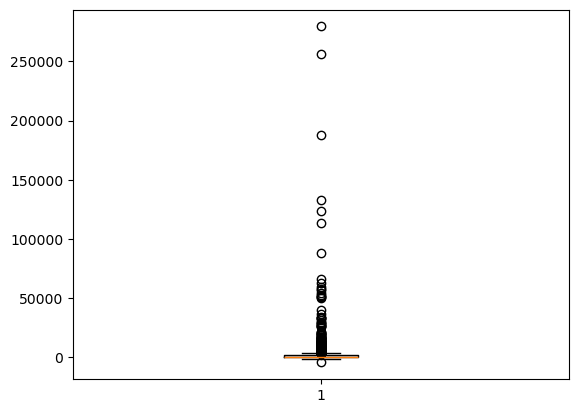

In [27]:
plt.boxplot(df1['Amount'])

There are 2 types of Outliers 
1. Statistical Outliers - where we dont really care about the variable itself or meaning of the variable itself - if it is more than
98% then we will consider as an Outlier
2. Domain Specific Outliers - Where we label a point as a Outlier based on the domain knowledge - in rare case we will consult with the client does this looks unusual? the outlier points 

Using Statistical method we planned to remove the statistical outliers

In [28]:
# removing (statistical) outliers
Q1 = df1.Amount.quantile(0.05)
Q3 = df1.Amount.quantile(0.95)
IQR = Q3 - Q1
df1 = df1[(df1.Amount >= Q1 - 1.5*IQR) & (df1.Amount <= Q3 + 1.5*IQR)]

# outlier treatment for recency
Q1 = df1.Recency.quantile(0.05)
Q3 = df1.Recency.quantile(0.95)
IQR = Q3 - Q1
df1 = df1[(df1.Recency >= Q1 - 1.5*IQR) & (df1.Recency <= Q3 + 1.5*IQR)]

# outlier treatment for frequency
Q1 = df1.Frequency.quantile(0.05)
Q3 = df1.Frequency.quantile(0.95)
IQR = Q3 - Q1
df1 = df1[(df1.Frequency >= Q1 - 1.5*IQR) & (df1.Frequency <= Q3 + 1.5*IQR)]

#### Now lets the Outliers for the Frequency variable 

{'whiskers': [<matplotlib.lines.Line2D at 0x23c43748740>,
 'caps': [<matplotlib.lines.Line2D at 0x23c436e83b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x23c437484a0>],
 'medians': [<matplotlib.lines.Line2D at 0x23c43749160>],
 'fliers': [<matplotlib.lines.Line2D at 0x23c43749460>],
 'means': []}

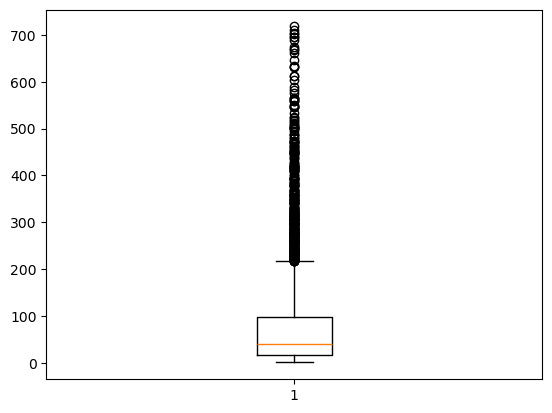

In [29]:
plt.boxplot(df1['Frequency'])

#### Now lets check the Outliers for Recency variable

<Axes: ylabel='Recency'>

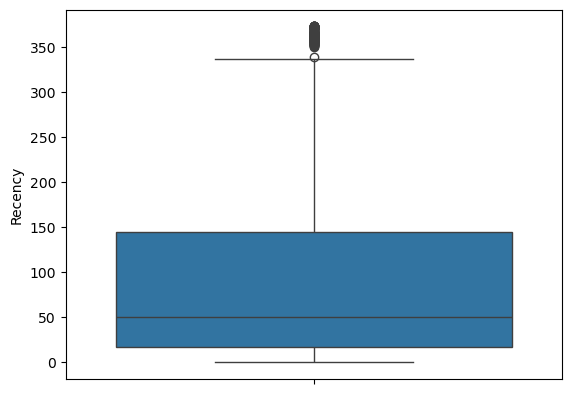

In [30]:
sns.boxplot(df1['Recency'])

##### we have seen the Outliers of the all the variables 
As of now we are not going to remove any of the Outliers as mentioned in the video - the outliers can be removed but those outliers may come
occur as a differnt clusters - so Removing Clusters are not an good ideas always - have a discussion with your client before you go head with the 
outliers




# Now lets Rescaling part 

We want to convert the RFM to the standard scaling - so we dont want customer id for scaling and also during the clustering process
So we can create a new DF with only the RFM variables to continue with the process

In [31]:
# Rescaling
rfmdf = df1[['Amount', 'Frequency', 'Recency']]
rfmdf.head()

,Amount,Frequency,Recency
0,0.00,2,325
1,4310.00,182,1
2,1797.24,31,74
3,1757.55,73,18
4,334.40,17,309


so now we are going to do scaling - as we already know we have 2 types of scaling Standard scaling and Normalization scaling 
Now we will use standard scaling for scale all the variables 
Lets import the libraries to perform the action 

In [32]:
import sklearn  
from sklearn.preprocessing import StandardScaler

In [33]:
# Instantiate 
scaler = StandardScaler()

In [34]:
# Fit Transform 
rfmdf_scaled = scaler.fit_transform(rfmdf)
rfmdf_scaled

array([[-0.72373821, -0.75288754,  2.30161144],
       [ 1.73161722,  1.04246665, -0.90646561],
       [ 0.30012791, -0.46363604, -0.18365813],
       ...,
       [-0.67769602, -0.70301659,  0.86589794],
       [-0.6231313 , -0.64317145, -0.84705678],
       [ 0.32293822, -0.07464263, -0.50050524]])

You can see all the variables are scaled between 0 & 1 - where 0 is Mean and 1 is standard deviation 

# Making the Cluster

Now let's begin the modelling part by creating the clusters using the SKlearn's K-means algorithm package.
We scaled the variables above which became numpy array - lets change it into Pd pandas - so that we can move with modelling part

In [35]:
rfmdf_scaled = pd.DataFrame(rfmdf_scaled)
rfmdf_scaled.columns = [['Amount', 'Frequency', 'Recency']]
rfmdf_scaled.head()

,Amount,Frequency,Recency
0,-0.723738,-0.752888,2.301611
1,1.731617,1.042467,-0.906466
2,0.300128,-0.463636,-0.183658
3,0.277517,-0.044720,-0.738141
4,-0.533235,-0.603275,2.143188


To continue with Modelling part - we need to import the required libraries 

In [36]:
from sklearn.cluster import KMeans

1st we will choose an arbitrary value of K and do clustering - random values for K 

then later will find some way to to choose the optimal number of K - optimal no of clusters 

1st thing we need to do is instantiate an object which is of the class K means use the below method to do the instantiate

In [37]:
kmeans = KMeans(n_clusters = 4, max_iter = 50)
kmeans.fit(rfmdf_scaled)

KMeans(max_iter=50, n_clusters=4)

This actually says - it found 4 clusters - lets see the labels of it 

In [38]:
kmeans.labels_

array([2, 1, 0, ..., 2, 0, 0])

In [40]:
len(kmeans.labels_)

4293

In the next segment, you will understand how to select the optimal number of clusters. 

# Optimal Number of Clusters

Now you might be thinking why the number of clusters is taken as 4 and not any other number. 

To find the optimum number of clusters, we use two techniques - the elbow curve method and the silhouette score method. 

Let's learn about both of them in detail in the following lecture.

### 1st is Elbow-curve 
elbow-curve/SSD (Sum of Squared Distances)

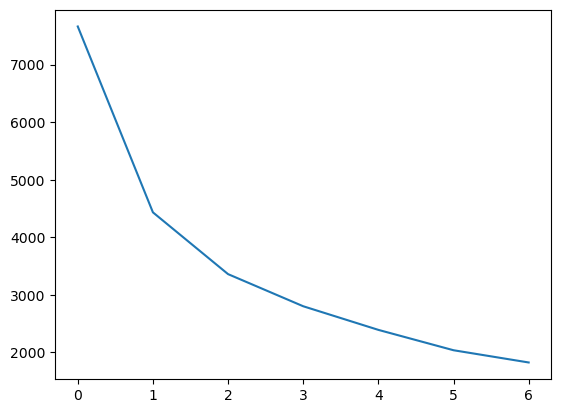

In [41]:
ssd=[]
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters = num_clusters , max_iter = 50)
    kmeans.fit(rfmdf_scaled)

    ssd.append(kmeans.inertia_)
# Plot the SSD for each n_clusters 
plt.plot(ssd)

### Silhouette Analysis

$$\text{silhouette score}=\frac{p-q}{max(p,q)}$$

$p$ is the mean distance to the points in the nearest cluster that the data point is not a part of

$q$ is the mean intra-cluster distance to all the points in its own cluster.

* The value of the silhouette score range lies between -1 to 1. 

* A score closer to 1 indicates that the data point is very similar to other data points in the cluster, 

* A score closer to -1 indicates that the data point is not similar to the data points in its cluster.

Let's go  ahead and take it a step further in Python.

Lets import the library 1st 

In [42]:
from sklearn.metrics import silhouette_score

In [43]:

range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    #intialise Kmeans
    kmeans = KMeans(n_clusters = num_clusters , max_iter = 50)
    kmeans.fit(rfmdf_scaled)

    cluster_labels = kmeans.labels_
    
    #Silhouette score
    silhouette_avg = silhouette_score(rfmdf_scaled, cluster_labels)
    print('For n_clusters={0}, the silhouette score is {1}'.format(num_clusters, silhouette_avg))

For n_clusters=2, the silhouette score is 0.4025940739563748
For n_clusters=3, the silhouette score is 0.5085084004374336
For n_clusters=4, the silhouette score is 0.48506020563508856
For n_clusters=5, the silhouette score is 0.464902620438719
For n_clusters=6, the silhouette score is 0.41698971636412085
For n_clusters=7, the silhouette score is 0.4150058806779277
For n_clusters=8, the silhouette score is 0.41375387600858776


# Cluster Analysis

##### First , we need to assign the Cluster IDs that we generated to each of the datapoints that we have with us. Let's go ahead and do that.

### Using above observation which is from KMeans and Silhouette - we can take 3 Clusters and build the final model

In [44]:
kmeans = KMeans(n_clusters = 3, max_iter = 50)
kmeans.fit(rfmdf_scaled)

KMeans(max_iter=50, n_clusters=3)

In [45]:
kmeans.labels_

array([0, 2, 1, ..., 0, 1, 1])

##### Assign the labels to the dataframe which has withe customer id in it
##### so data frame df1 has the data with the customer id in it 

In [46]:
df1.head()

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309


Add the kmeans.labels_ to the above data frame

In [47]:
df1['Cluster_id'] = kmeans.labels_
df1.head()

,CustomerID,Amount,Frequency,Recency,Cluster_id
0,12346.0,0.00,2,325,0
1,12347.0,4310.00,182,1,2
2,12348.0,1797.24,31,74,1
3,12349.0,1757.55,73,18,1
4,12350.0,334.40,17,309,0


The next step is interesting because we need to perform a bit of outlier analysis once again to understand how the dataset works here.

<Axes: xlabel='Cluster_id', ylabel='Amount'>

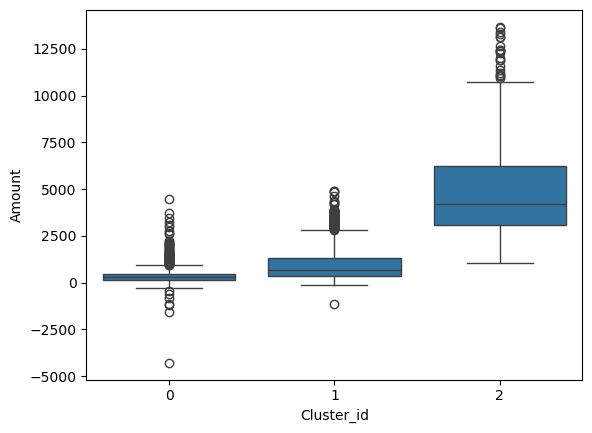

In [48]:
sns.boxplot(x='Cluster_id', y='Amount', data = df1)

In [ ]:
##### 0 - Average customers     1 - Low level customers     2 - High level customers

<Axes: xlabel='Cluster_id', ylabel='Frequency'>

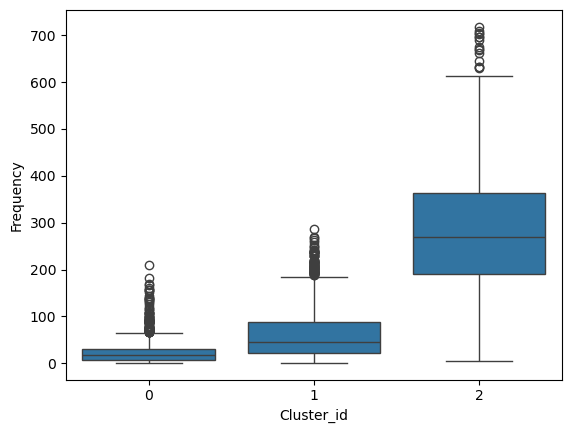

In [49]:
sns.boxplot(x='Cluster_id', y='Frequency', data = df1)

2 - High frequency customers     1 - low Frequecy     0 - Average Frequency 

<Axes: xlabel='Cluster_id', ylabel='Recency'>

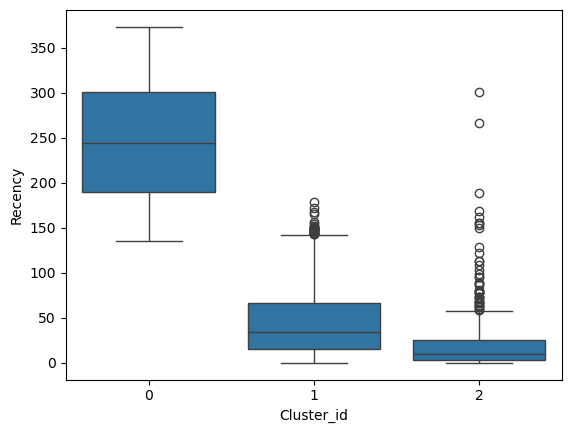

In [51]:
sns.boxplot(x='Cluster_id', y='Recency', data = df1)

# Hierarchical Clustering Algorithm 
We will use the same online retail case study and data set that we used for the K-Means algorithm. 
For making the customer segments this time, we will use the hierarchical algorithm.
 

We will start at the point where we are done with the data preparation and already have the RFM dat
aset which has been treated for missing values and outliers, and is also standardi
.

 

The hierarchical clustering involves 2 basi
cCreating the dendrogram, 



Cutting the dendrogram at an appropriate level
iate level



Now let's go ahead and utilise the single linkage method for clustering this dataset.

#### Lets import few of the required libraries for Hierarchical Clustering

In [52]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

Scipy stands for Scientific Python 

In [53]:
# lets start from here where we have the RFM data frame
rfmdf_scaled.head()

,Amount,Frequency,Recency
0,-0.723738,-0.752888,2.301611
1,1.731617,1.042467,-0.906466
2,0.300128,-0.463636,-0.183658
3,0.277517,-0.044720,-0.738141
4,-0.533235,-0.603275,2.143188


In [54]:
# Lets take this df as we have cluster id in it 
df1.head()

,CustomerID,Amount,Frequency,Recency,Cluster_id
0,12346.0,0.00,2,325,0
1,12347.0,4310.00,182,1,2
2,12348.0,1797.24,31,74,1
3,12349.0,1757.55,73,18,1
4,12350.0,334.40,17,309,0


### 1st we will try the Single Linkage Clustering 

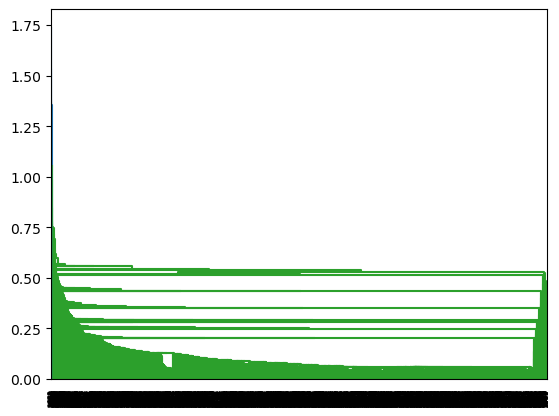

In [55]:
mergings = linkage (rfmdf_scaled, method = 'single', metric = 'euclidean')
dendrogram(mergings)
plt.show()

Since we have used single linkage - we are not getting the clear picture of the dendrogram 
lets try the same with the other linkage method 

As you can clearly see, single linkage doesn't produce a good enough result for us to analyse the clusters. 
Hence, we need to go ahead and utilise the complete linkage method and then analyse the clusters once again.

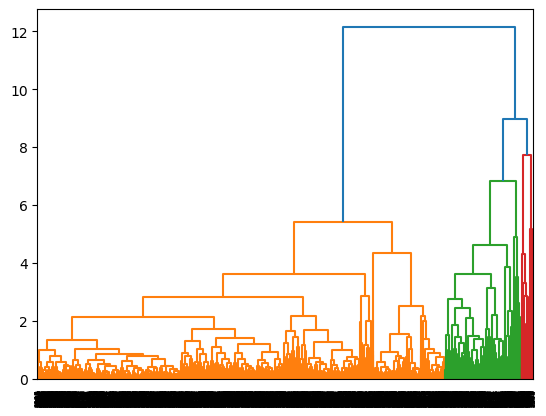

In [56]:
### Complete Linkage 
mergings = linkage (rfmdf_scaled, method = 'complete', metric = 'euclidean')
dendrogram(mergings)
plt.show()

### Let's move to the next part - Cut tree 

we will try to have 3 clusters which means k=3 

Lets see how to do that 

In [60]:
cut_tree(mergings,n_clusters=3)

array([[0],
       [1],
       [0],
       ...,
       [0],
       [0],
       [0]], dtype=int64)

In [61]:
cut_tree(mergings,n_clusters=3).shape

(4293, 1)

shape() ---> this is used to call a method 


without () - shape <- ----> it is called as attribute 

so now we need to add the above cut_tree cluster output to our df1 data set - but the shape of both the df(df1 &cut_tree(mergings,n_clusters=3)) looks differnt just have a look below

In [57]:
df1.shape

(4293, 5)

to resolve this issue - we need to  reshape the cut_tree(mergings,n_clusters=3) array output as mentioned below

In [59]:
Cluster_labels = cut_tree(mergings,n_clusters=3).reshape(-1, )
Cluster_labels

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

In [60]:
df1['Cluster_labels'] = Cluster_labels
df1.head()

,CustomerID,Amount,Frequency,Recency,Cluster_id,Cluster_labels
0,12346.0,0.00,2,325,0,0
1,12347.0,4310.00,182,1,2,1
2,12348.0,1797.24,31,74,1,0
3,12349.0,1757.55,73,18,1,0
4,12350.0,334.40,17,309,0,0


### Cluster_ id we got it from K-Means and Cluster_Labels got it from Hierarchical Clustering Algorithm 

#### Lets have a plot and see how both output looks like 

<Axes: xlabel='Cluster_labels', ylabel='Amount'>

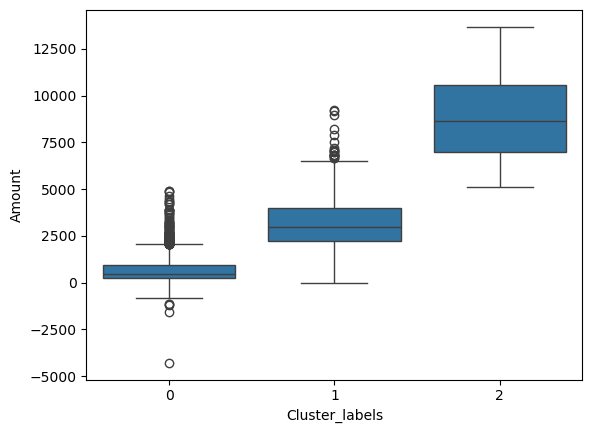

In [61]:
sns.boxplot(x='Cluster_labels', y='Amount', data = df1)

<Axes: xlabel='Cluster_labels', ylabel='Recency'>

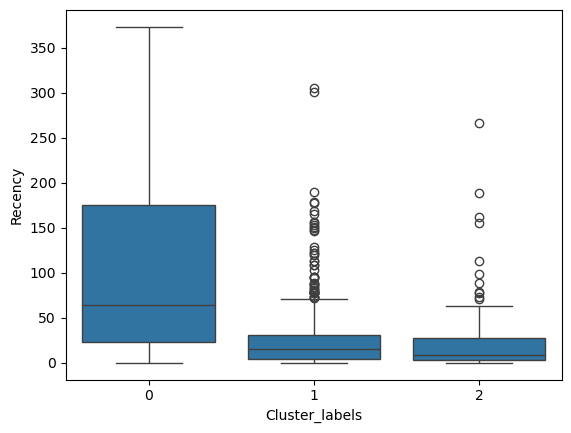

In [66]:
sns.boxplot(x='Cluster_labels', y='Recency', data = df1)

<Axes: xlabel='Cluster_labels', ylabel='Frequency'>

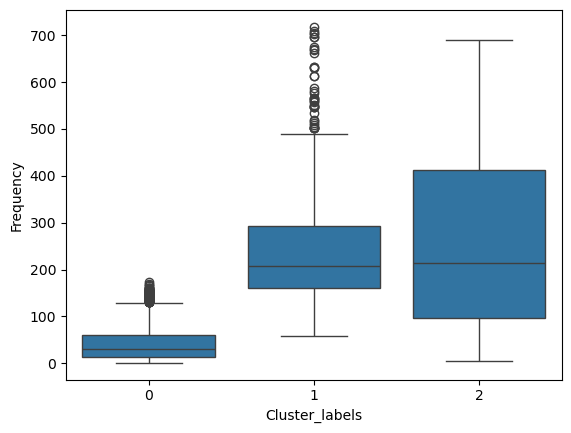

In [64]:
sns.boxplot(x='Cluster_labels', y='Frequency', data = df1)

After we got the clusterIDs for each customer, we then appended the obtained ClusterIDs to the RFM data set, and analysed the characteristics of each 
cluster to derive the business insights from the different customer segments or clusters, in the same way as you did for the K-Means algorithm.